In [1]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

sns.set()


In [2]:
print("Loading trained model...")

model_data = joblib.load(
    "/home/kali/Documents/Intrusion-Detection-System-IDS-using-Neural-Networks/Hybrid-ids/Model/random_forest_model.pkl"
)

model = model_data["model"]
scaler = model_data["scaler"]
encoders = model_data["encoders"]

print("Model loaded successfully!")


Loading trained model...
Model loaded successfully!


### load test data set

In [3]:
test_data = pd.read_csv("/home/kali/Downloads/test.csv")
test_data.rename(columns={"class": "label"}, inplace=True)

print("Test Dataset Loaded.")
print("Shape:", test_data.shape)

test_data.head()


Test Dataset Loaded.
Shape: (34394, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,13,tcp,telnet,SF,118,2425,0,0,0,0,...,10,0.38,0.12,0.04,0.0,0.00,0.00,0.12,0.3,anomaly
1,0,udp,private,SF,44,0,0,0,0,0,...,254,1.00,0.01,0.01,0.0,0.00,0.00,0.00,0.0,anomaly
2,0,tcp,telnet,S3,0,44,0,0,0,0,...,79,0.31,0.61,0.00,0.0,0.21,0.68,0.60,0.0,anomaly
3,0,udp,private,SF,53,55,0,0,0,0,...,255,1.00,0.00,0.87,0.0,0.00,0.00,0.00,0.0,normal
4,0,tcp,private,SH,0,0,0,0,0,0,...,1,0.06,1.00,1.00,0.0,1.00,1.00,0.00,0.0,anomaly


### Encoding categorical columns using same encoder

In [4]:
categorical_cols = ["protocol_type", "service", "flag"]

for col in categorical_cols:
    test_data[col] = encoders[col].transform(test_data[col])

# Convert labels to binary
test_data["label"] = test_data["label"].map({"normal": 0, "anomaly": 1})

print("Encoding completed.")



Encoding completed.


### Prepare features

In [5]:
X_test = test_data.drop("label", axis=1)
y_true = test_data["label"]

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")


Feature scaling completed.


### ML Batch Prediction

In [6]:
print("Starting Batch Prediction...")

ml_predictions = model.predict(X_test_scaled)

print("ML Prediction Completed.")


Starting Batch Prediction...


ML Prediction Completed.


### Simulated signature based detection (snort logic)

In [7]:
def simulate_snort(row):
    if row["serror_rate"] > 0.5:
        return 1
    if row["src_bytes"] > 10000:
        return 1
    return 0

snort_predictions = test_data.apply(simulate_snort, axis=1).values

print("Signature-based simulation completed.")


Signature-based simulation completed.


### hybrid OR logic

In [8]:
hybrid_predictions = np.where(
    (ml_predictions == 1) | (snort_predictions == 1),
    1,
    0
)

print("Hybrid decision logic applied.")


Hybrid decision logic applied.


### Evaluation (ML mode)

In [9]:
print("========== ML MODEL RESULTS ==========")
print(classification_report(y_true, ml_predictions))


========== ML MODEL RESULTS ==========
              precision    recall  f1-score   support

           0       0.54      0.96      0.69     11863
           1       0.96      0.58      0.72     22531

    accuracy                           0.71     34394
   macro avg       0.75      0.77      0.71     34394
weighted avg       0.82      0.71      0.71     34394



### Evaluating signature based 

In [10]:
print("========== SNORT SIMULATION RESULTS ==========")
print(classification_report(y_true, snort_predictions))

========== SNORT SIMULATION RESULTS ==========
              precision    recall  f1-score   support

           0       0.41      0.98      0.58     11863
           1       0.96      0.25      0.39     22531

    accuracy                           0.50     34394
   macro avg       0.68      0.61      0.48     34394
weighted avg       0.77      0.50      0.46     34394



### Hybrid Model

In [11]:
print("========== HYBRID MODEL RESULTS ==========")
print(classification_report(y_true, hybrid_predictions))


========== HYBRID MODEL RESULTS ==========
              precision    recall  f1-score   support

           0       0.58      0.94      0.72     11863
           1       0.95      0.64      0.77     22531

    accuracy                           0.75     34394
   macro avg       0.77      0.79      0.74     34394
weighted avg       0.83      0.75      0.75     34394



### Confusion matrix (hybrid)

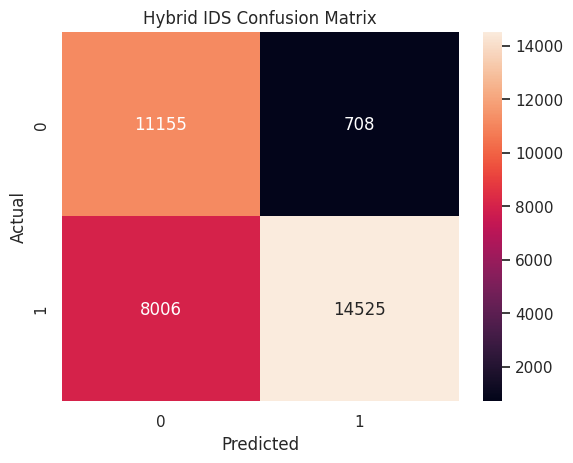

Hybrid IDS Simulation Completed Successfully!


In [12]:
cm = confusion_matrix(y_true, hybrid_predictions)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Hybrid IDS Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("Hybrid IDS Simulation Completed Successfully!")